# EduPredict-XAI

## Step 15 — Baseline Model Training

**Research Topic:** Student Performance Prediction Using Explainable AI

**Student:** Payal Pramod Pawar  
**Program:** MCA Sem 3  
**Guide:** Mrs. Shaesta Mujawar

### Objective

The objective of this notebook is to establish baseline machine learning performance using:

- CatBoost
- XGBoost
- LightGBM

The models will be trained using the same training and testing split.

The models will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These results will later be compared with the main TabPFN model.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("All libraries imported successfully.")
 

All libraries imported successfully.


In [2]:
# Define project paths
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed data:")
print(PROCESSED_DATA_PATH)

Project root:
d:\MCA Sem 3\RP\EduPredict-XAI

Processed data:
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed


In [3]:
# Load the feature-engineered dataset
DATA_PATH = (
    PROCESSED_DATA_PATH /
    "student_performance_feature_engineered.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (1000, 10)


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3
3,Male,2.6,77.5,8.0,High School,Yes,Yes,No,85.1,83.8
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3


In [4]:
# Define target
TARGET = "final_exam_score"

print("Target:", TARGET)
print("Target exists:", TARGET in df.columns)

Target: final_exam_score
Target exists: True


In [5]:
# Separate X and y
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 9)
y shape: (1000,)


In [6]:
# Create the SAME train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 9)
Testing data: (200, 9)


In [7]:
# Identify categorical columns
categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade']

Categorical features:
['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']


In [8]:
# Prepare CatBoost data
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in categorical_features:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

cat_feature_indices = [
    X_train_cat.columns.get_loc(col)
    for col in categorical_features
]

print("CatBoost categorical feature indices:")
print(cat_feature_indices)

CatBoost categorical feature indices:
[0, 4, 5, 6, 7]


In [ ]:
# Train CatBoost (MODEL 1)
catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_feature_indices
)

print("CatBoost training completed successfully.")

CatBoost training completed successfully.


In [10]:
# Generate CatBoost predictions
y_pred_catboost = catboost_model.predict(
    X_test_cat
)

print("CatBoost predictions generated.")
print("Number of predictions:", len(y_pred_catboost))

CatBoost predictions generated.
Number of predictions: 200


In [12]:
# Evaluate CatBoost
def evaluate_model(model_name, y_true, y_pred):
    
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

catboost_result = evaluate_model(
    "CatBoost",
    y_test,
    y_pred_catboost
)

print(catboost_result)

{'Model': 'CatBoost', 'MAE': 5.346275507760982, 'RMSE': np.float64(6.810512807355598), 'R2': 0.5690784497376355}


In [ ]:
# Prepare XGBoost
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder,
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [15]:
# Fit preprocessing ONLY on training data
X_train_encoded = preprocessor.fit_transform(
    X_train
)

X_test_encoded = preprocessor.transform(
    X_test
)

print("X_train encoded shape:", X_train_encoded.shape)
print("X_test encoded shape:", X_test_encoded.shape)

X_train encoded shape: (800, 16)
X_test encoded shape: (200, 16)


In [16]:
# Get feature names
encoded_feature_names = (
    preprocessor.get_feature_names_out()
)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

print("Encoded data prepared.")
print("Final encoded feature count:",
      X_train_encoded.shape[1])

Encoded data prepared.
Final encoded feature count: 16


In [ ]:
# Train XGBoost (MODEL 2)
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_encoded,
    y_train
)

print("XGBoost training completed successfully.")

XGBoost training completed successfully.


In [18]:
# XGBoost predictions
y_pred_xgb = xgb_model.predict(
    X_test_encoded
)

print("XGBoost predictions generated.")
print("Number of predictions:", len(y_pred_xgb))

XGBoost predictions generated.
Number of predictions: 200


In [19]:
# Evaluate XGBoost
xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb
)

print(xgb_result)

{'Model': 'XGBoost', 'MAE': 5.796503929138182, 'RMSE': np.float64(7.3318546494228825), 'R2': 0.5005795990154327}


In [20]:
# Train LightGBM (MODEL 3)
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train_encoded,
    y_train
)

print("LightGBM training completed successfully.")

LightGBM training completed successfully.


In [21]:
# LightGBM predictions
y_pred_lgbm = lgbm_model.predict(
    X_test_encoded
)

print("LightGBM predictions generated.")
print("Number of predictions:", len(y_pred_lgbm))

LightGBM predictions generated.
Number of predictions: 200


In [22]:
# Evaluate LightGBM
lgbm_result = evaluate_model(
    "LightGBM",
    y_test,
    y_pred_lgbm
)

print(lgbm_result)

{'Model': 'LightGBM', 'MAE': 6.082376565845707, 'RMSE': np.float64(7.554698660384332), 'R2': 0.46975952273035315}


In [23]:
# Create the baseline comparison table
baseline_results = pd.DataFrame([
    catboost_result,
    xgb_result,
    lgbm_result
])

baseline_results = baseline_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(baseline_results)

,Model,MAE,RMSE,R2
0,CatBoost,5.346276,6.810513,0.569078
1,XGBoost,5.796504,7.331855,0.500580
2,LightGBM,6.082377,7.554699,0.469760


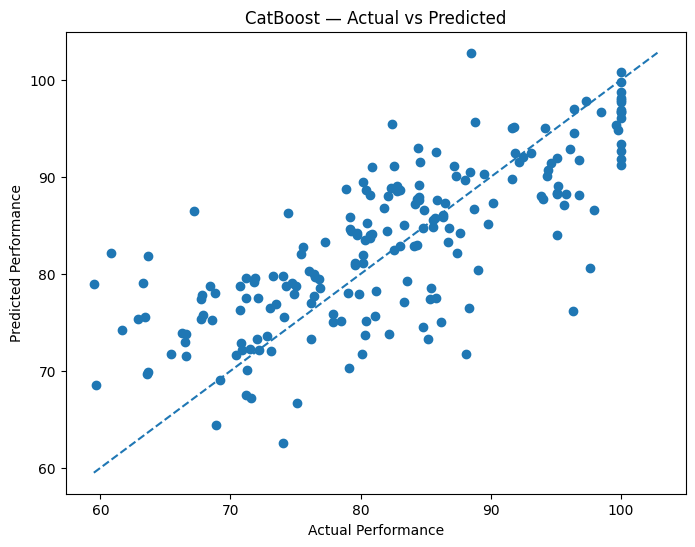

In [ ]:
# Compare actual vs predicted values of CatBoost.
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_catboost
)

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("CatBoost — Actual vs Predicted")

min_value = min(
    y_test.min(),
    y_pred_catboost.min()
)

max_value = max(
    y_test.max(),
    y_pred_catboost.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

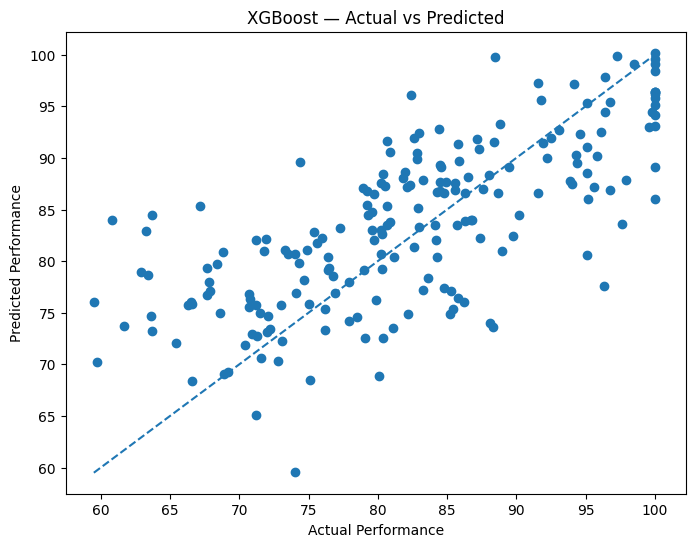

In [25]:
# Compare actual vs predicted values of XGBoost.
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_xgb
)

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("XGBoost — Actual vs Predicted")

min_value = min(y_test.min(), y_pred_xgb.min())
max_value = max(y_test.max(), y_pred_xgb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

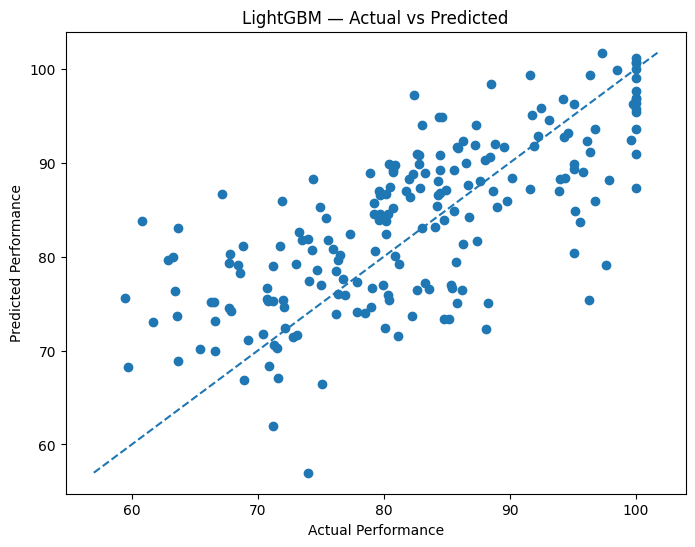

In [26]:
# Compare actual vs predicted values of LightGBM.
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lgbm
)

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("LightGBM — Actual vs Predicted")

min_value = min(y_test.min(), y_pred_lgbm.min())
max_value = max(y_test.max(), y_pred_lgbm.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

In [27]:
# CatBoost feature importance
catboost_importance = pd.DataFrame({
    "Feature": X_train_cat.columns,
    "Importance": catboost_model.feature_importances_
})

catboost_importance = catboost_importance.sort_values(
    by="Importance",
    ascending=False
)

display(catboost_importance)

,Feature,Importance
1,study_time_hours,32.841313
8,previous_grade,22.965975
2,attendance_percent,17.689033
3,sleep_hours,8.003415
5,internet_access,6.351545
7,part_time_job,5.531011
4,parental_education,3.644250
6,extracurricular_activities,1.777140
0,gender,1.196319


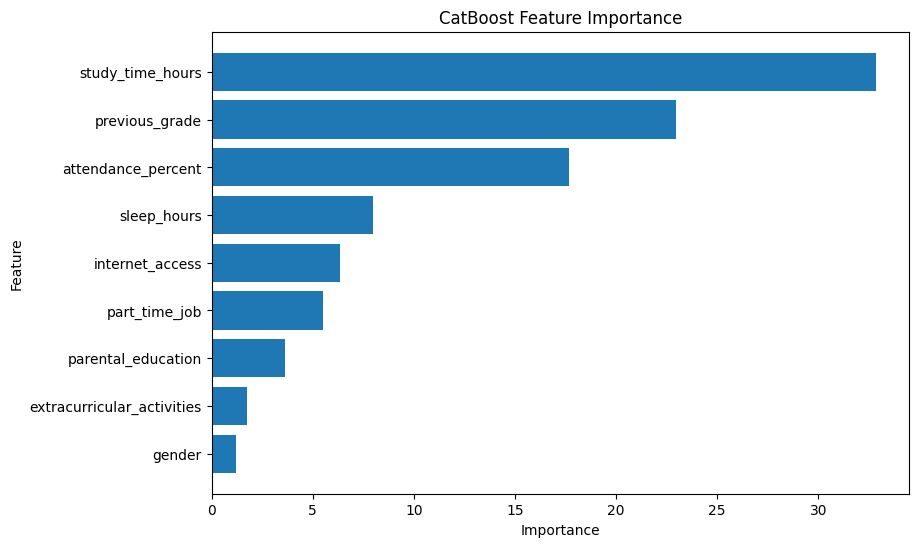

In [28]:
# Visualize CatBoost feature importance
plt.figure(figsize=(9, 6))

plt.barh(
    catboost_importance["Feature"],
    catboost_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [29]:
# Save baseline results
RESULTS_PATH = PROJECT_ROOT / "results"

RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

baseline_results_path = (
    RESULTS_PATH /
    "baseline_model_results.csv"
)

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

print("Baseline results saved:")
print(baseline_results_path)

Baseline results saved:
d:\MCA Sem 3\RP\EduPredict-XAI\results\baseline_model_results.csv


In [33]:
# Save the trained models
import joblib

MODELS_PATH = PROJECT_ROOT / "models"

MODELS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

catboost_model.save_model(
    MODELS_PATH / "catboost_baseline.cbm"
)

print("CatBoost model saved.")

joblib.dump(
    xgb_model,
    MODELS_PATH / "xgboost_baseline.pkl"
)

print("XGBoost model saved.")

joblib.dump(
    lgbm_model,
    MODELS_PATH / "lightgbm_baseline.pkl"
)

print("LightGBM model saved.")

CatBoost model saved.
XGBoost model saved.
LightGBM model saved.


In [34]:
# Save the XGBoost/LightGBM preprocessing pipeline
joblib.dump(
    preprocessor,
    MODELS_PATH / "categorical_preprocessor.pkl"
)

print("Preprocessing pipeline saved.")

Preprocessing pipeline saved.


In [37]:
# Final Step 15 summary
print("=" * 65)
print("STEP 15 — BASELINE MODEL TRAINING COMPLETED")
print("=" * 65)

display(baseline_results)

print("\nModels trained:")
print("✓ CatBoost")
print("✓ XGBoost")
print("✓ LightGBM")

print("\nEvaluation metrics:")
print("✓ MAE")
print("✓ RMSE")
print("✓ R²")


STEP 15 — BASELINE MODEL TRAINING COMPLETED


,Model,MAE,RMSE,R2
0,CatBoost,5.346276,6.810513,0.569078
1,XGBoost,5.796504,7.331855,0.500580
2,LightGBM,6.082377,7.554699,0.469760



Models trained:
✓ CatBoost
✓ XGBoost
✓ LightGBM

Evaluation metrics:
✓ MAE
✓ RMSE
✓ R²
